In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

In [4]:
dataset=pd.read_csv("StudentsPerformance.csv")

In [6]:
dataset.shape

(1000, 8)

In [7]:
dataset.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:
dataset = dataset.rename(columns = {
    "race/ethnicity": "race",
    "parental level of education": "parent_edu",
    "test preparation course": "test_course",
    "math score": "math_score",
    "reading score": "reading_score",
    "writing score": "writing_score"
})
dataset

,gender,race,parent_edu,lunch,test_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [13]:
dataset["total_score"]=dataset["math_score"]+dataset["reading_score"]+dataset["writing_score"]

In [14]:
dataset.head()

,gender,race,parent_edu,lunch,test_course,math_score,reading_score,writing_score,total_score
0,female,group B,bachelor's degree,standard,none,74,74,74,222
1,female,group C,some college,standard,completed,88,88,88,264
2,female,group B,master's degree,standard,none,93,93,93,279
3,male,group A,associate's degree,free/reduced,none,44,44,44,132
4,male,group C,some college,standard,none,75,75,75,225


In [15]:
dataset.isnull().sum()

gender           0
race             0
parent_edu       0
lunch            0
test_course      0
math_score       0
reading_score    0
writing_score    0
total_score      0
dtype: int64

In [19]:
dataset.loc[len(dataset)]=[
    "male",
    "group A",
    np.nan,
    "standard",
    np.nan,
    78,
    56,
    89,
    223
]

In [21]:
dataset.isnull().sum()

gender           0
race             0
parent_edu       1
lunch            0
test_course      1
math_score       0
reading_score    0
writing_score    0
total_score      0
dtype: int64

<AxesSubplot:ylabel='reading_score'>

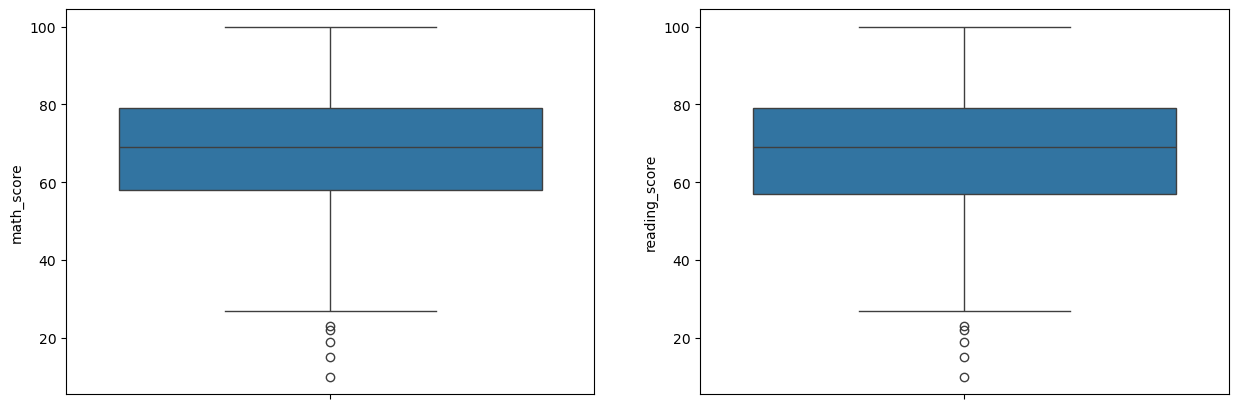

In [29]:
fig,axes = plt.subplots(1,2, figsize=(15,5))

sns.boxplot(data=dataset["math_score"], ax=axes[0])
sns.boxplot(data=dataset["reading_score"], ax=axes[1])

In [31]:
dataset["math_zscore"]=stats.zscore(dataset["math_score"]) #Calculates the Z-score for every value in the math_score column.
#z=x-mean/std

In [32]:
dataset["math_outlier"]=np.where( #new column to store outlier
    np.abs(dataset["math_zscore"])>3, #take the absolute value from math_zscore column
    "outlier", #if true write outlier
    np.nan
)

In [33]:
dataset.head()

,gender,race,parent_edu,lunch,test_course,math_score,reading_score,writing_score,total_score,math_zscore,math_outlier
0,female,group B,bachelor's degree,standard,none,74,74,74,222,0.390949,nan
1,female,group C,some college,standard,completed,88,88,88,264,1.312989,nan
2,female,group B,master's degree,standard,none,93,93,93,279,1.642289,nan
3,male,group A,associate's degree,free/reduced,none,44,44,44,132,-1.584851,nan
4,male,group C,some college,standard,none,75,75,75,225,0.456809,nan


In [34]:
dataset["reading_zscore"]=stats.zscore(dataset["reading_score"])

In [35]:
dataset["reading_outlier"]=np.where(
    np.abs(dataset["reading_zscore"])>3,
    "outlier",
    np.nan
)

In [36]:
dataset.head()

,gender,race,parent_edu,lunch,test_course,math_score,reading_score,writing_score,total_score,math_zscore,math_outlier,reading_zscore,reading_outlier
0,female,group B,bachelor's degree,standard,none,74,74,74,222,0.390949,nan,0.392357,nan
1,female,group C,some college,standard,completed,88,88,88,264,1.312989,nan,1.314305,nan
2,female,group B,master's degree,standard,none,93,93,93,279,1.642289,nan,1.643572,nan
3,male,group A,associate's degree,free/reduced,none,44,44,44,132,-1.584851,nan,-1.583245,nan
4,male,group C,some college,standard,none,75,75,75,225,0.456809,nan,0.458211,nan


In [40]:
scaler=MinMaxScaler() #create the instance

In [41]:
dataset["total_score_scaled"]=scaler.fit_transform(dataset[["total_score"]]) #fit calculate min max of the column

In [42]:
dataset[["total_score", "total_score_scaled"]].head()


,total_score,total_score_scaled
0,222,0.711111
1,264,0.866667
2,279,0.922222
3,132,0.377778
4,225,0.722222
